### Import the data

Fri Oct 10 14:31:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:C1:00.0 Off |                   On |
| N/A   27C    P0             84W /  500W |      91MiB /  81920MiB |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

100%|██████████| 2702/2702 [00:08<00:00, 324.32it/s]


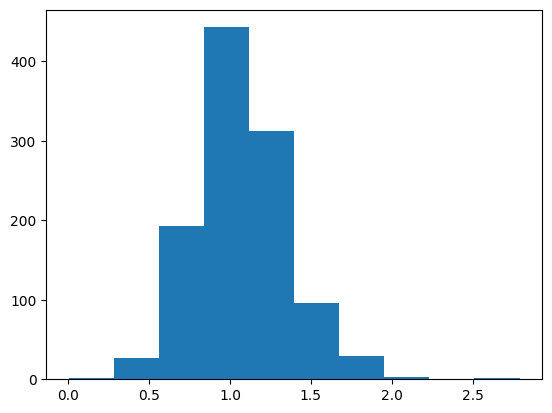

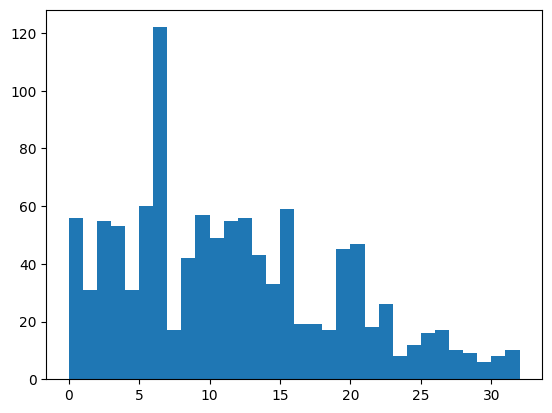

In [1]:
%run  Data_preparation_TCGA.ipynb
## More information about the dataset can be found in Data_preparation_TCGA.ipynb

### Import the model

In [2]:
from Reconstructing_model import *

### Traning Process

In [3]:
train_loader = DataLoader(training_set, batch_size=128, shuffle=True)
test_loader = DataLoader(testing_set, batch_size=1024, shuffle=False)

In [4]:
torch.manual_seed(0)

num_hiddens_genotype = 16
num_hiddens_final = 16

model = Drugcell_Vae(term_size_map, term_direct_gene_map, dG, num_genes, 
                 root, num_hiddens_genotype, num_hiddens_final, n_class = len(cancer_2_idx))

In [5]:
def create_term_mask(term_direct_gene_map, gene_dim, device):

    term_mask_map = {}

    for term, gene_set in term_direct_gene_map.items():

        mask = torch.zeros(len(gene_set), gene_dim)

        for i, gene_id in enumerate(gene_set):
            mask[i, gene_id] = 1

        mask_gpu = torch.autograd.Variable(mask)

        term_mask_map[term] = mask_gpu.to(device)

    return term_mask_map

term_mask_map = create_term_mask(model.term_direct_gene_map, num_genes, device = DEVICE)


In [6]:
# parameters
model.to(DEVICE)
learning_rate = 0.001
torch.manual_seed(0)
loss_list = []
accu_list = []
train_epochs = 500
ssl_epochs = 100

In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.99), eps=1e-05, weight_decay= 1e-4)
term_mask_map = create_term_mask(model.term_direct_gene_map, gene_dim=num_genes, device=DEVICE)

optimizer.zero_grad()

for name, param in model.named_parameters():
    term_name = name.split('_')[0]

    if '_direct_gene_layer.weight' in name:
        param.data = torch.mul(param.data, term_mask_map[term_name].to(DEVICE)) * 1
    else:
        param.data = param.data * 1

tepoch = tqdm.tqdm(range(train_epochs))
for epoch in tepoch:
    # Train
    model.train()
    train_predict = torch.zeros(0, 0).to(DEVICE)

    for i, (data, labels) in enumerate(train_loader):
        # Convert torch tensor to Variable

        # Forward + Backward + Optimize
        optimizer.zero_grad()  # zero the gradient buffer

        # mask for SSL
        masked_data, mask = model.mask_input(data.to(DEVICE), mask_ratio=0.15)

        # Here term_NN_out_map is a dictionary
        logits, mu, log_var, aux_out_map, aux_cancer_map, term_NN_out_map, term_original_children = model(masked_data.to(DEVICE))

        if train_predict.size()[0] == 0:
            train_predict = aux_out_map["final"].data
        else:
            train_predict = torch.cat([train_predict, aux_out_map["final"].data], dim=0)

        total_loss = 0

        loss_vae = model.loss_log_vae(
            recon_mean=logits, y=data.to(DEVICE), mu=mu, log_var=log_var, beta=0.001
        )

        loss_intermidiate = model.intermediate_loss(aux_out_map, term_original_children)

        loss_intermidiate_cancer = model.intermediate_loss_cancer(aux_cancer_map, labels.to(DEVICE))


        s_loss = model.sparse_loss(recon_mean = logits, sparsity_target = 0.1, sparsity_weight = 0.1)

        inter_s_loss = model.contrastive_loss_with_sparsity(aux_out_map, term_original_children, 0.1, 0.1)

        recon_loss = ((logits - data.to(DEVICE)) ** 2)[mask].mean()

        total_loss = 0.5 * recon_loss + torch.mean(loss_vae + model.inter_loss_penalty * 0.01 * loss_intermidiate + 0.2 * inter_s_loss + 0.1 * s_loss)
        
        
        
        tmp_loss = total_loss.item() - recon_loss
        
        total_loss.backward()

        for name, param in model.named_parameters():
            if "_direct_gene_layer.weight" not in name:
                continue
            term_name = name.split("_")[0]
            # print name, param.grad.data.size(), term_mask_map[term_name].size()
            if param.requires_grad and param.grad is not None:
                term_name = name.split("_")[0]
                param.grad.data = torch.mul(param.grad.data, term_mask_map[term_name])

        optimizer.step()

    with torch.no_grad():

        model.eval()

        (inputdata, labels) = next(iter(test_loader))

        loss_inter = model.inter_loss_penalty * 0.1 * loss_intermidiate

        recon, mu, log_var, aux_out_map, aux_cancer_map, term_NN_out_map, term_original_children = model(inputdata.to(DEVICE))

        sim = F.cosine_similarity(recon.to(DEVICE), inputdata.to(DEVICE), dim=1)
        sim = sim.mean()

    

    tepoch.set_postfix({"Epoch": epoch, "Loss": tmp_loss,  "Similarity": sim})
    
    loss_list.append(tmp_loss)
    # if epoch % 10 == 0:
    # torch.save(model, "model_032_updated.pt")


print(f'loss_vae: {loss_vae}')
print(f'loss_inter origi: {loss_intermidiate}, in function: {loss_inter}')

  1%|          | 3/500 [01:26<3:58:42, 28.82s/it, Epoch=2, Loss=tensor(926.2495, device='cuda:0', grad_fn=<RsubBackward1>), Similarity=tensor(0.5579, device='cuda:0')]


KeyboardInterrupt: 